# Mental Health Text Classifier
## Friend 1: Yubraj Parajuli
### Data Pipeline, EDA, ML Training

## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Step 2: Load Data

In [4]:
df = pd.read_csv('../data/raw/mental_heath_unbanlanced.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (49612, 3)

Columns: ['Unique_ID', 'text', 'status']

First 5 rows:


,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


## Step 3: Data Cleaning

### Step 3.1: Inspect Data

In [5]:
print("Shape:", df.shape)
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicates:", df['text'].duplicated().sum())
print("\nClass Distribution:")
print(df['status'].value_counts())
print("\nText Length Stats:")
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
print(df[['text_length', 'word_count']].describe())

Shape: (49612, 3)

Null Values:
Unique_ID    9600
text            0
status          0
dtype: int64

Duplicates: 667

Class Distribution:
status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

Text Length Stats:
        text_length    word_count
count  49612.000000  49612.000000
mean     399.227143     78.229199
std      617.780591    122.187106
min        7.000000      1.000000
25%       74.000000     14.000000
50%      242.000000     47.000000
75%      559.000000    110.000000
max    38785.000000   9684.000000


### Step 3.2: Apply Cleaning

In [6]:
# Drop Unique_ID
df = df.drop(columns=['Unique_ID'])

# Drop duplicate texts
df = df.drop_duplicates(subset='text')

# Remove very short texts
df = df[df['word_count'] >= 3]

# Remove extremely long texts above 99th percentile
max_len = df['text_length'].quantile(0.99)
df = df[df['text_length'] <= max_len]

# Reset index
df = df.reset_index(drop=True)

print("Final Shape:", df.shape)
print("\nClass Distribution:")
print(df['status'].value_counts())
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicates:", df['text'].duplicated().sum())

Final Shape: (47972, 4)

Class Distribution:
status
Normal        17672
Depression    14131
Suicidal      10981
Anxiety        5188
Name: count, dtype: int64

Null Values:
text           0
status         0
text_length    0
word_count     0
dtype: int64

Duplicates: 0


## Step 4: Text Preprocessing

In [7]:
import re
import unicodedata

def preprocess_text(text):
    # unicode normalization
    text = unicodedata.normalize("NFKD", text)
    # lowercase
    text = text.lower()
    # remove html tags
    text = re.sub(r"<.*?>", "", text)
    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)
    # remove emails
    text = re.sub(r"\S+@\S+", "", text)
    # remove hashtags and mentions
    text = re.sub(r"[@#]\S+", "", text)
    # remove tabs and newlines
    text = text.replace("\t", " ").replace("\n", " ")
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].astype(str).apply(preprocess_text)

print("Sample before and after preprocessing:")
for i in range(3):
    print(f"\nOriginal : {df['text'].iloc[i]}")
    print(f"Cleaned  : {df['clean_text'].iloc[i]}")

print(f"\nTotal samples after preprocessing: {len(df)}")

Sample before and after preprocessing:

Original : oh my gosh
Cleaned  : oh my gosh

Original : trouble sleeping, confused mind, restless heart. All out of tune
Cleaned  : trouble sleeping, confused mind, restless heart. all out of tune

Original : All wrong, back off dear, forward doubt. Stay in a restless and restless place
Cleaned  : all wrong, back off dear, forward doubt. stay in a restless and restless place

Total samples after preprocessing: 47972


## Step 4: EDA & Visualizations

### Step 4.1: Class Distribution

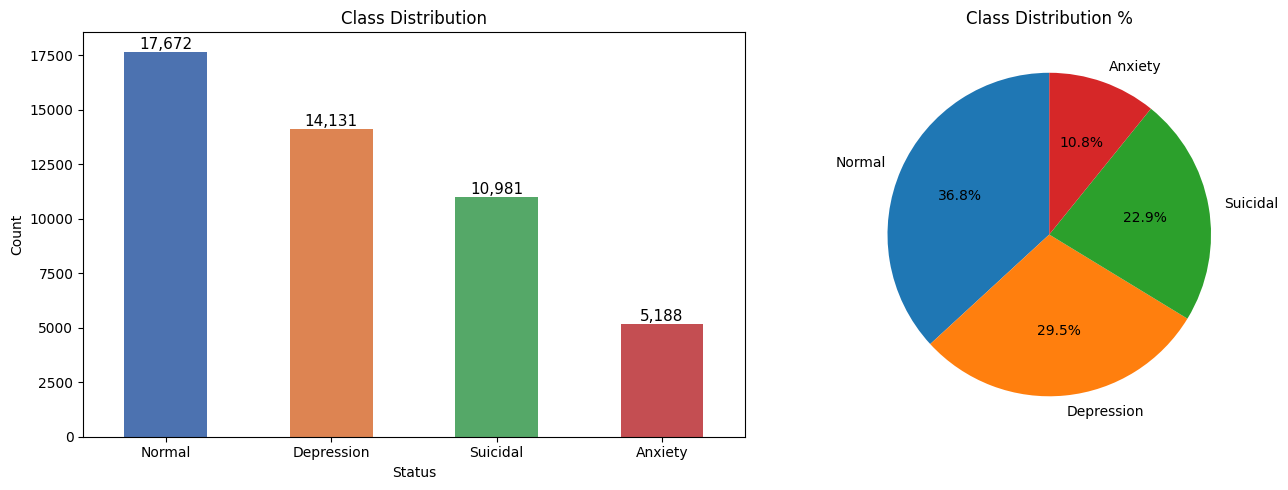

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df['status'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
df['status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

### Step 4.2: Text Length Analysis

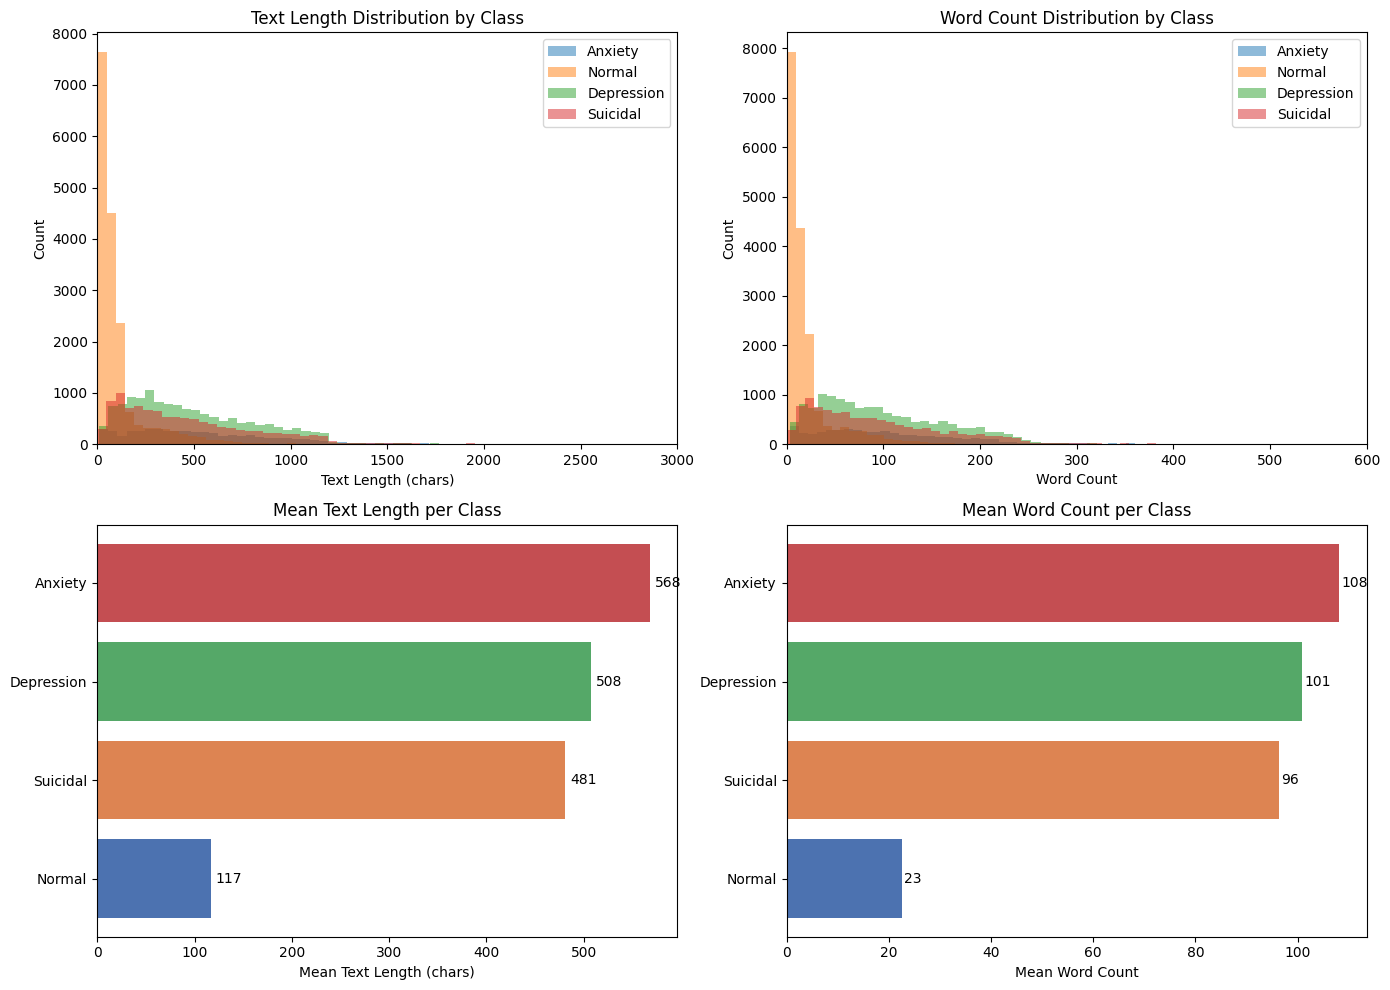


Text Length Stats per Class:
           clean_text_length                  clean_word_count                
                        mean median min   max             mean median min  max
status                                                                        
Anxiety               567.87  485.0  10  2381           108.15   92.0   3  473
Depression            507.79  435.0  10  2387           100.94   87.0   3  484
Normal                116.82   61.0   5  2334            22.53   12.0   1  456
Suicidal              481.11  387.0   0  2384            96.30   78.0   0  466


In [9]:
df['clean_text_length'] = df['clean_text'].astype(str).apply(len)
df['clean_word_count'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Text length distribution by class
for label in df['status'].unique():
    subset = df[df['status'] == label]['clean_text_length']
    axes[0, 0].hist(subset, bins=50, alpha=0.5, label=label)
axes[0, 0].set_title('Text Length Distribution by Class')
axes[0, 0].set_xlabel('Text Length (chars)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 3000)

# Word count distribution by class
for label in df['status'].unique():
    subset = df[df['status'] == label]['clean_word_count']
    axes[0, 1].hist(subset, bins=50, alpha=0.5, label=label)
axes[0, 1].set_title('Word Count Distribution by Class')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 600)

# Mean text length per class
mean_text = df.groupby('status')['clean_text_length'].mean().sort_values()
axes[1, 0].barh(mean_text.index, mean_text.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1, 0].set_title('Mean Text Length per Class')
axes[1, 0].set_xlabel('Mean Text Length (chars)')
for i, v in enumerate(mean_text.values):
    axes[1, 0].text(v + 5, i, f'{v:.0f}', va='center')

# Mean word count per class
mean_words = df.groupby('status')['clean_word_count'].mean().sort_values()
axes[1, 1].barh(mean_words.index, mean_words.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1, 1].set_title('Mean Word Count per Class')
axes[1, 1].set_xlabel('Mean Word Count')
for i, v in enumerate(mean_words.values):
    axes[1, 1].text(v + 0.5, i, f'{v:.0f}', va='center')

plt.tight_layout()
plt.savefig('../outputs/text_length_analysis.png', dpi=150)
plt.show()

print("\nText Length Stats per Class:")
print(df.groupby('status')[['clean_text_length', 'clean_word_count']].agg(['mean', 'median', 'min', 'max']).round(2))

### Step 4.4: Word Cloud per Class

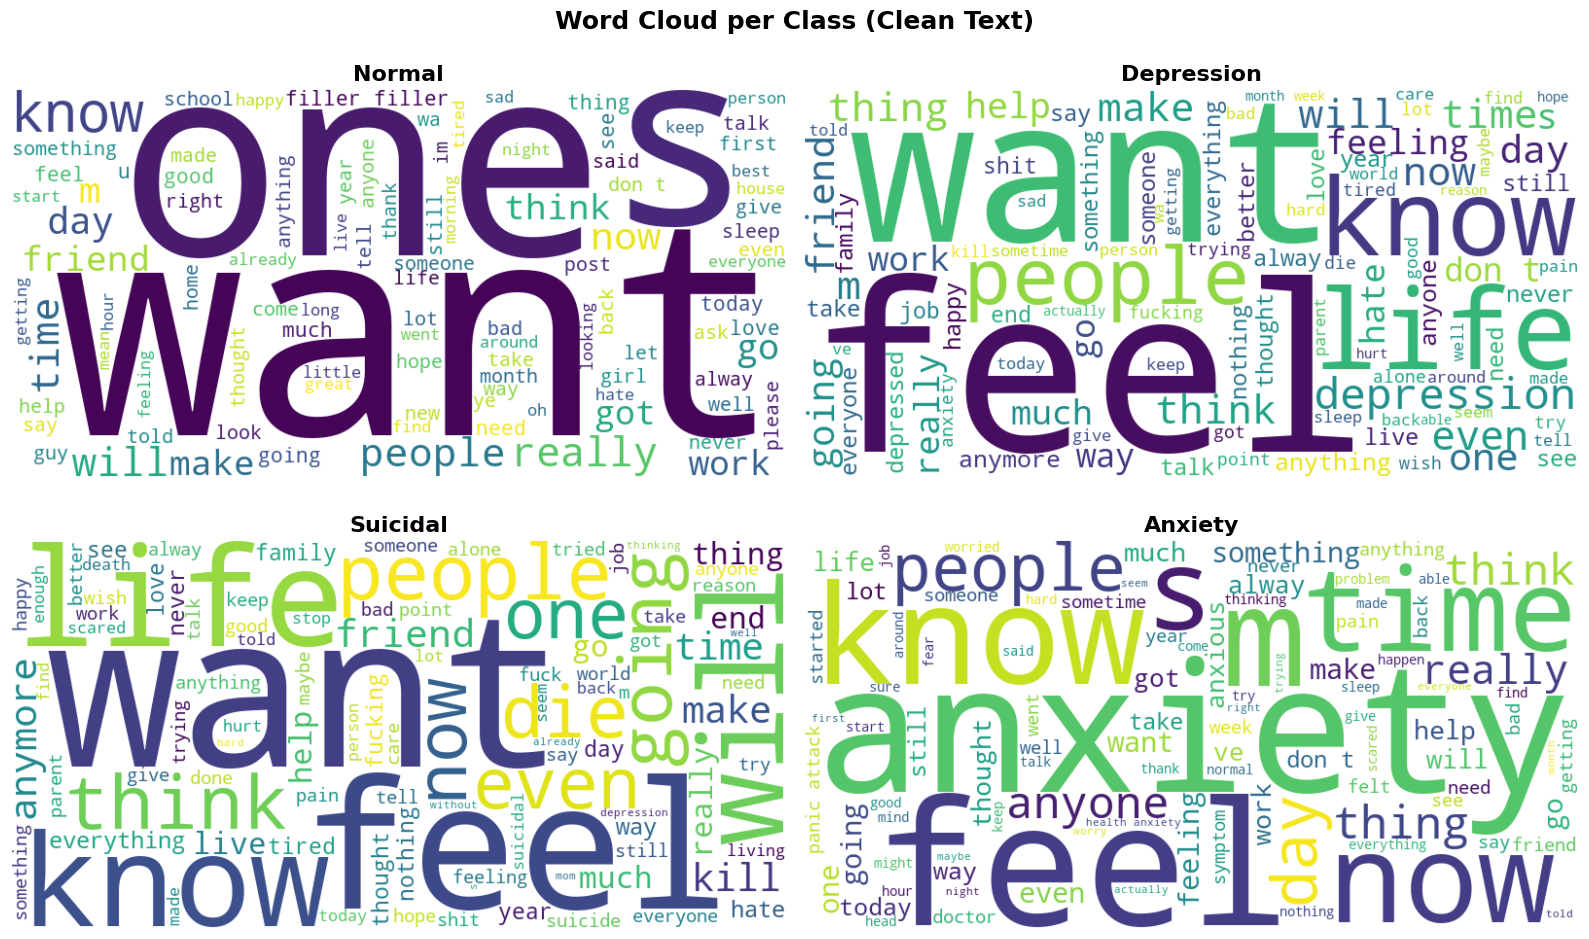

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, label in enumerate(['Normal', 'Depression', 'Suicidal', 'Anxiety']):
    text = ' '.join(df[df['status'] == label]['clean_text'].astype(str).tolist())
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{label}', fontsize=16, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Cloud per Class (Clean Text)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/wordclouds_clean.png', dpi=150)
plt.show()

### Step 4.5: Top 15 Most Frequent Words per Class

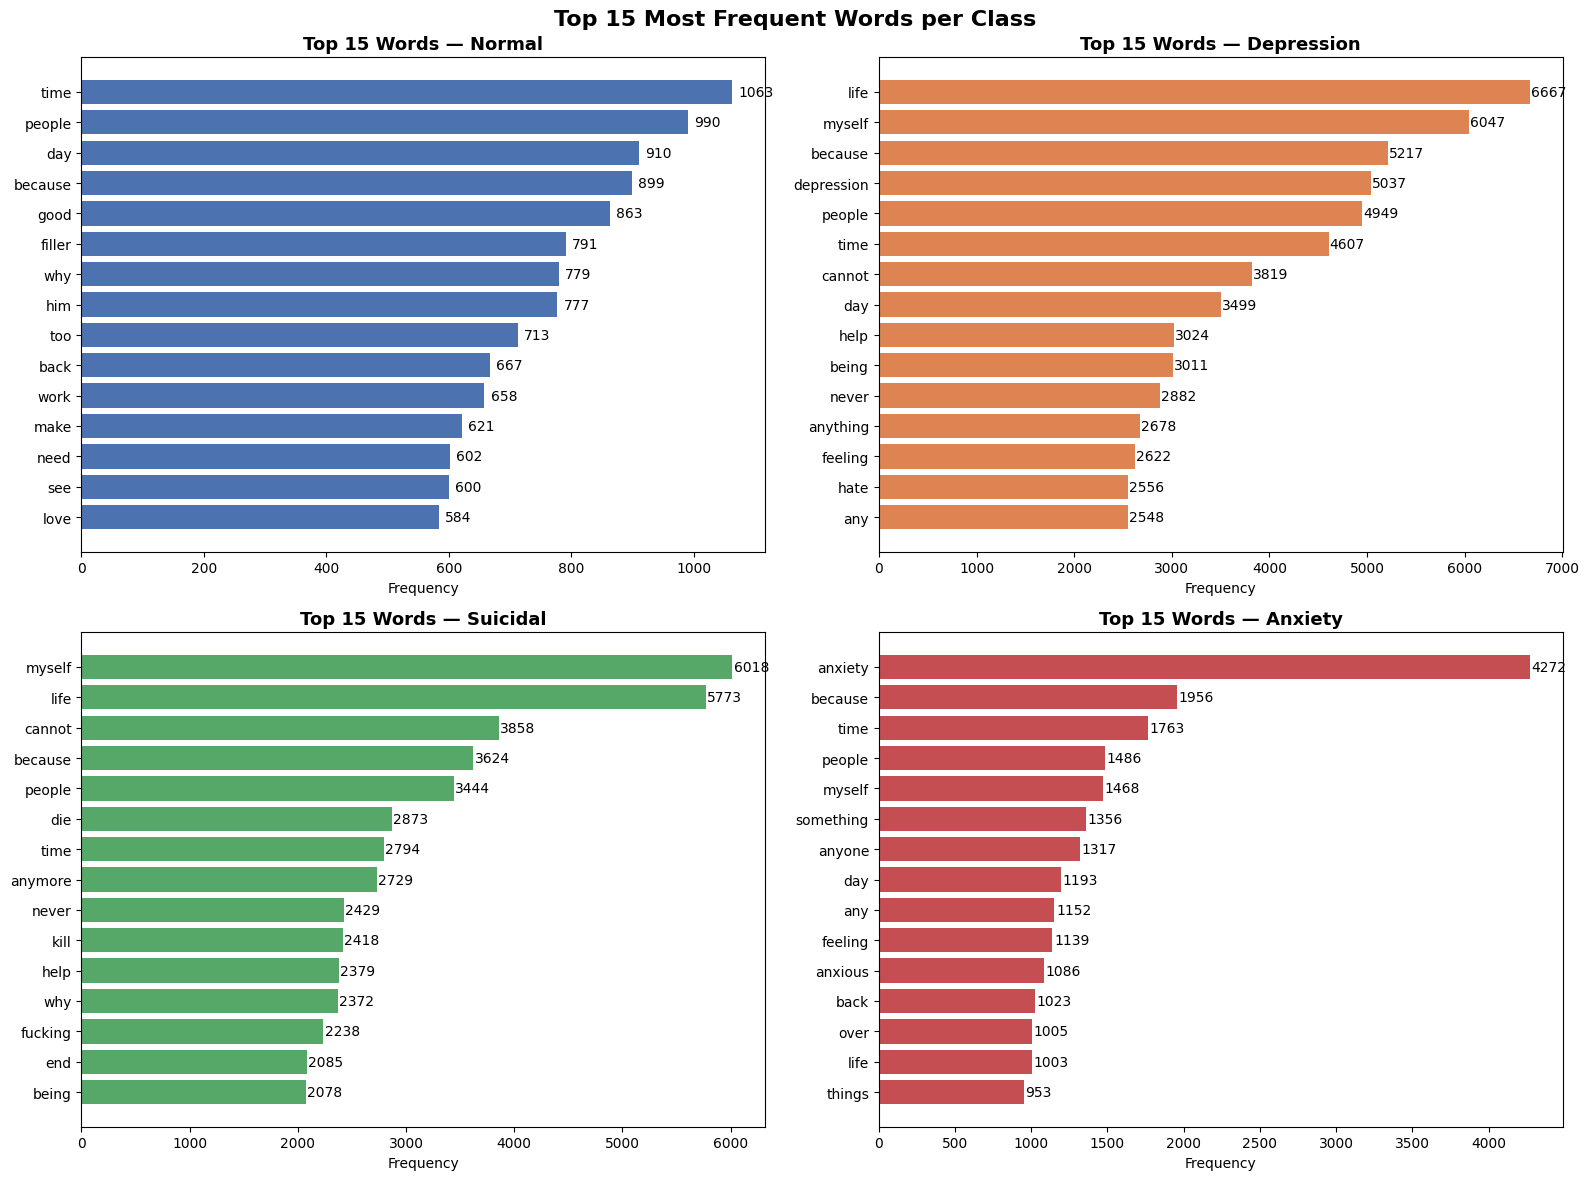

In [11]:
from collections import Counter
import re

stopwords = set(['i', 'me', 'my', 'the', 'a', 'an', 'and', 'or', 'but', 'in', 
                 'on', 'at', 'to', 'for', 'of', 'with', 'is', 'it', 'this', 
                 'that', 'was', 'are', 'be', 'as', 'so', 'do', 'if', 'not',
                 'have', 'has', 'had', 'he', 'she', 'they', 'we', 'you', 'your',
                 'his', 'her', 'their', 'our', 'its', 'been', 'will', 'would',
                 'can', 'could', 'should', 'may', 'might', 'from', 'by', 'about',
                 'just', 'get', 'got', 'like', 'up', 'out', 'there', 'what',
                 'when', 'who', 'how', 'all', 'no', 'more', 'some', 'than',
                 'then', 'them', 'these', 'those', 'into', 'also', 'only',
                 'am', 've', 're', 'll', 't', 's', 'm', 'don', 'didn', 'doesn',
                 'wasn', 'aren', 'won', 'can', 'one', 'now', 'know', 'want',
                 'feel', 'think', 'really', 'even', 'still', 'much', 'going'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, label in enumerate(['Normal', 'Depression', 'Suicidal', 'Anxiety']):
    text = ' '.join(df[df['status'] == label]['clean_text'].astype(str).tolist())
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    words = [w for w in words if w not in stopwords]
    top_words = Counter(words).most_common(15)
    words_list, counts = zip(*top_words)

    axes[i].barh(words_list[::-1], counts[::-1], 
                 color=['#4C72B0','#DD8452','#55A868','#C44E52'][i])
    axes[i].set_title(f'Top 15 Words — {label}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Frequency')
    for j, v in enumerate(counts[::-1]):
        axes[i].text(v + 10, j, str(v), va='center')

plt.suptitle('Top 15 Most Frequent Words per Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/top_words_per_class.png', dpi=150)
plt.show()

### Step 5.5: Class Imbalance Ratio

Class Counts:
status
Normal        17672
Depression    14131
Suicidal      10981
Anxiety        5188
Name: count, dtype: int64

Imbalance Ratio (max/min): 3.41x

Most frequent class: Normal (17,672)
Least frequent class: Anxiety (5,188)


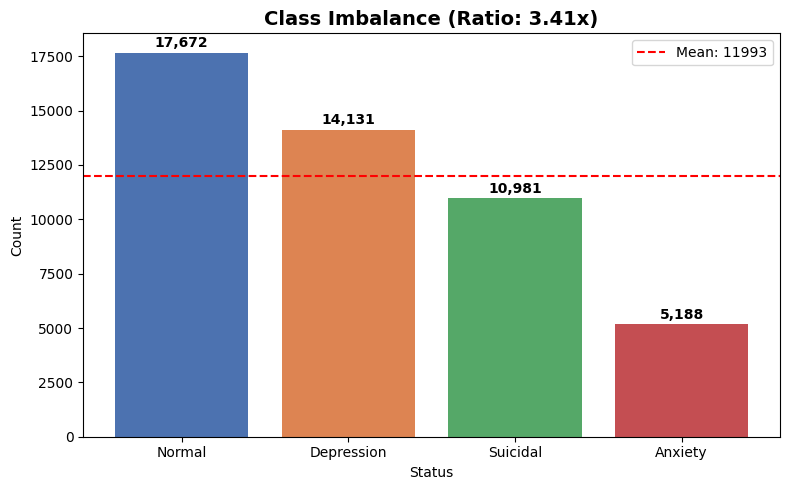

In [12]:
class_counts = df['status'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class Counts:")
print(class_counts)
print(f"\nImbalance Ratio (max/min): {imbalance_ratio:.2f}x")
print(f"\nMost frequent class: {class_counts.idxmax()} ({class_counts.max():,})")
print(f"Least frequent class: {class_counts.idxmin()} ({class_counts.min():,})")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
bars = ax.bar(class_counts.index, class_counts.values, color=colors)
ax.axhline(y=class_counts.mean(), color='red', linestyle='--', label=f'Mean: {class_counts.mean():.0f}')
ax.set_title(f'Class Imbalance (Ratio: {imbalance_ratio:.2f}x)', fontsize=14, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.legend()
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/class_imbalance.png', dpi=150)
plt.show()

## Step 6: Label Encoding & Train/Val Split

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Label encoding
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['status'])

print("Label Mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} → {i}")

# Train/Val split (80/20 stratified)
train_df, val_df = train_test_split(
    df[['clean_text', 'status', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nTrain size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"\nTrain class distribution:")
print(train_df['status'].value_counts())
print(f"\nVal class distribution:")
print(val_df['status'].value_counts())

Label Mapping:
  Anxiety → 0
  Depression → 1
  Normal → 2
  Suicidal → 3

Train size: 38377
Val size:   9595

Train class distribution:
status
Normal        14137
Depression    11305
Suicidal       8785
Anxiety        4150
Name: count, dtype: int64

Val class distribution:
status
Normal        3535
Depression    2826
Suicidal      2196
Anxiety       1038
Name: count, dtype: int64


## Step 7: Class Weights Computation

In [14]:
import torch
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} → {class_weights[i]:.4f}")

print(f"\nClass weights tensor: {class_weights_tensor}")

Class Weights:
  Anxiety → 2.3119
  Depression → 0.8487
  Normal → 0.6787
  Suicidal → 1.0921

Class weights tensor: tensor([2.3119, 0.8487, 0.6787, 1.0921])


## Step 8: Baseline ML Models

### Step 8.1: Logistic Regression, Naive Bayes, Random Forest

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train_df['clean_text'])
X_val = tfidf.transform(val_df['clean_text'])
y_train = train_df['label']
y_val = val_df['label']

print(f"TF-IDF matrix shape: {X_train.shape}")

# Models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    elapsed = time.time() - start

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')
    results[name] = {'Accuracy': acc, 'Macro F1': f1, 'Time': f'{elapsed:.1f}s'}

    print(f"\n{name}")
    print(f"  Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Time: {elapsed:.1f}s")
    print(classification_report(y_val, preds, target_names=label_encoder.classes_))

TF-IDF matrix shape: (38377, 50000)

Logistic Regression
  Accuracy: 0.7844 | Macro F1: 0.7695 | Time: 3.6s
              precision    recall  f1-score   support

     Anxiety       0.72      0.85      0.78      1038
  Depression       0.75      0.63      0.68      2826
      Normal       0.89      0.93      0.91      3535
    Suicidal       0.69      0.73      0.71      2196

    accuracy                           0.78      9595
   macro avg       0.76      0.78      0.77      9595
weighted avg       0.78      0.78      0.78      9595


Naive Bayes
  Accuracy: 0.7089 | Macro F1: 0.6524 | Time: 0.0s
              precision    recall  f1-score   support

     Anxiety       0.92      0.31      0.47      1038
  Depression       0.54      0.80      0.65      2826
      Normal       0.89      0.85      0.87      3535
    Suicidal       0.73      0.55      0.63      2196

    accuracy                           0.71      9595
   macro avg       0.77      0.63      0.65      9595
weighted avg 

### Step 8.2: SVM

In [17]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

start = time.time()
svm = LinearSVC(class_weight='balanced', max_iter=1000, random_state=42)
svm.fit(X_train, y_train)
preds = svm.predict(X_val)
elapsed = time.time() - start

acc = accuracy_score(y_val, preds)
f1 = f1_score(y_val, preds, average='macro')
results['SVM'] = {'Accuracy': acc, 'Macro F1': f1, 'Time': f'{elapsed:.1f}s'}

print(f"SVM (LinearSVC)")
print(f"  Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Time: {elapsed:.1f}s")
print(classification_report(y_val, preds, target_names=label_encoder.classes_))

SVM (LinearSVC)
  Accuracy: 0.7828 | Macro F1: 0.7683 | Time: 1.5s
              precision    recall  f1-score   support

     Anxiety       0.79      0.79      0.79      1038
  Depression       0.72      0.66      0.69      2826
      Normal       0.89      0.94      0.91      3535
    Suicidal       0.68      0.69      0.69      2196

    accuracy                           0.78      9595
   macro avg       0.77      0.77      0.77      9595
weighted avg       0.78      0.78      0.78      9595



### Step 8.3 : Save Model,Label and Vector

In [34]:
import joblib
import os

# create folder
os.makedirs("models", exist_ok=True)

# 1. Save label encoder 
joblib.dump(label_encoder, "models/label_encoder.pkl")

# 2. Save TF-IDF vectorizer
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

# 3. Save models
joblib.dump(models['Logistic Regression'], "models/logistic_regression.pkl")
joblib.dump(models['Naive Bayes'], "models/naive_bayes.pkl")
joblib.dump(models['Random Forest'], "models/random_forest.pkl")
joblib.dump(svm, "models/svm.pkl")

print("All models saved successfully in 'models/' folder")

All models saved successfully in 'models/' folder


In [41]:
# checking if saved model works or not
tfidf = joblib.load("models/tfidf_vectorizer.pkl")
label_encoder = joblib.load("models/label_encoder.pkl")

log_reg = joblib.load("models/logistic_regression.pkl")
nb = joblib.load("models/naive_bayes.pkl")
rf = joblib.load("models/random_forest.pkl")
svm = joblib.load("models/svm.pkl")

In [47]:
text = ["I feel very sad and hopeless"]
X = tfidf.transform(text)

print("SVM:", label_encoder.inverse_transform([svm.predict(X)[0]])[0])
print("LogReg:", label_encoder.inverse_transform([log_reg.predict(X)[0]])[0])
print("NB:", label_encoder.inverse_transform([nb.predict(X)[0]])[0])
print("RF:", label_encoder.inverse_transform([rf.predict(X)[0]])[0])

SVM: Depression
LogReg: Normal
NB: Depression
RF: Normal


## Step 9: ML Results Comparison

ML Models Comparison:
                     Accuracy  Macro F1   Time
Logistic Regression    0.7844    0.7695   3.6s
SVM                    0.7828    0.7683   1.5s
Random Forest          0.7199    0.6777  12.2s
Naive Bayes            0.7089    0.6524   0.0s


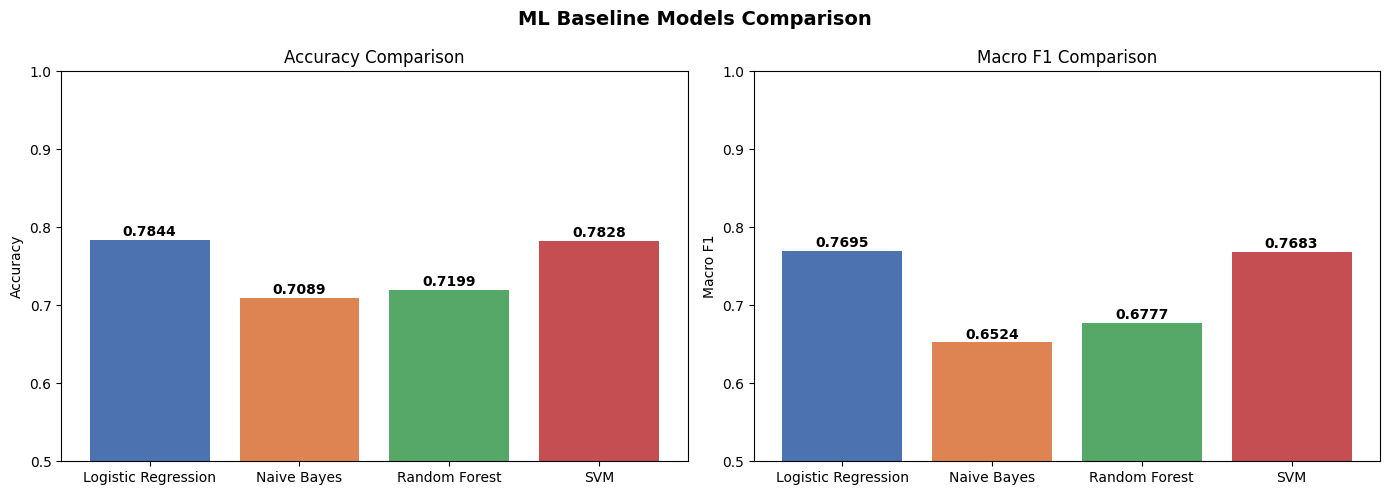

In [18]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df['Accuracy'] = results_df['Accuracy'].astype(float).round(4)
results_df['Macro F1'] = results_df['Macro F1'].astype(float).round(4)
print("ML Models Comparison:")
print(results_df.sort_values('Macro F1', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_names = list(results.keys())
accuracies = [results[m]['Accuracy'] for m in models_names]
f1_scores = [results[m]['Macro F1'] for m in models_names]

axes[0].bar(models_names, accuracies, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(models_names, f1_scores, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Macro F1 Comparison')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0.5, 1.0)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('ML Baseline Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/ml_comparison.png', dpi=150)
plt.show()

### Step 9.2: Error Analysis on Validation Data

In [19]:
# Get predictions from best ML model (Logistic Regression)
lr_model = models['Logistic Regression']
val_preds = lr_model.predict(X_val)
val_true = y_val.values

# Add predictions to val_df
val_df['lr_pred'] = label_encoder.inverse_transform(val_preds)
val_df['true_label'] = label_encoder.inverse_transform(val_true)

# Find misclassified samples
errors = val_df[val_df['lr_pred'] != val_df['true_label']]
correct = val_df[val_df['lr_pred'] == val_df['true_label']]

print(f"Total val samples:    {len(val_df)}")
print(f"Correct predictions:  {len(correct)}")
print(f"Wrong predictions:    {len(errors)}")
print(f"Error rate:           {len(errors)/len(val_df)*100:.2f}%")

print(f"\nMost common misclassifications:")
error_pairs = errors.groupby(['true_label', 'lr_pred']).size().sort_values(ascending=False).head(10)
print(error_pairs)

print(f"\nSample misclassified texts:")
print("-" * 80)
for _, row in errors.sample(5, random_state=42).iterrows():
    print(f"True:      {row['true_label']}")
    print(f"Predicted: {row['lr_pred']}")
    print(f"Text:      {row['clean_text'][:200]}")
    print("-" * 80)

Total val samples:    9595
Correct predictions:  7526
Wrong predictions:    2069
Error rate:           21.56%

Most common misclassifications:
true_label  lr_pred   
Depression  Suicidal      662
Suicidal    Depression    422
Depression  Anxiety       207
            Normal        189
Suicidal    Normal        142
Normal      Depression    107
            Anxiety       103
Anxiety     Depression     76
            Normal         67
Normal      Suicidal       52
dtype: int64

Sample misclassified texts:
--------------------------------------------------------------------------------
True:      Suicidal
Predicted: Depression
Text:      wtf is wrong with my brain i do not understand it does not stop fucking stop just stop why does not it stop
--------------------------------------------------------------------------------
True:      Depression
Predicted: Suicidal
Text:      i guess in some ways i am doing better than most. i still have a job - a good job - but... there is just nothing to 

### Step 9.3: Confusion Matrix for ML Models

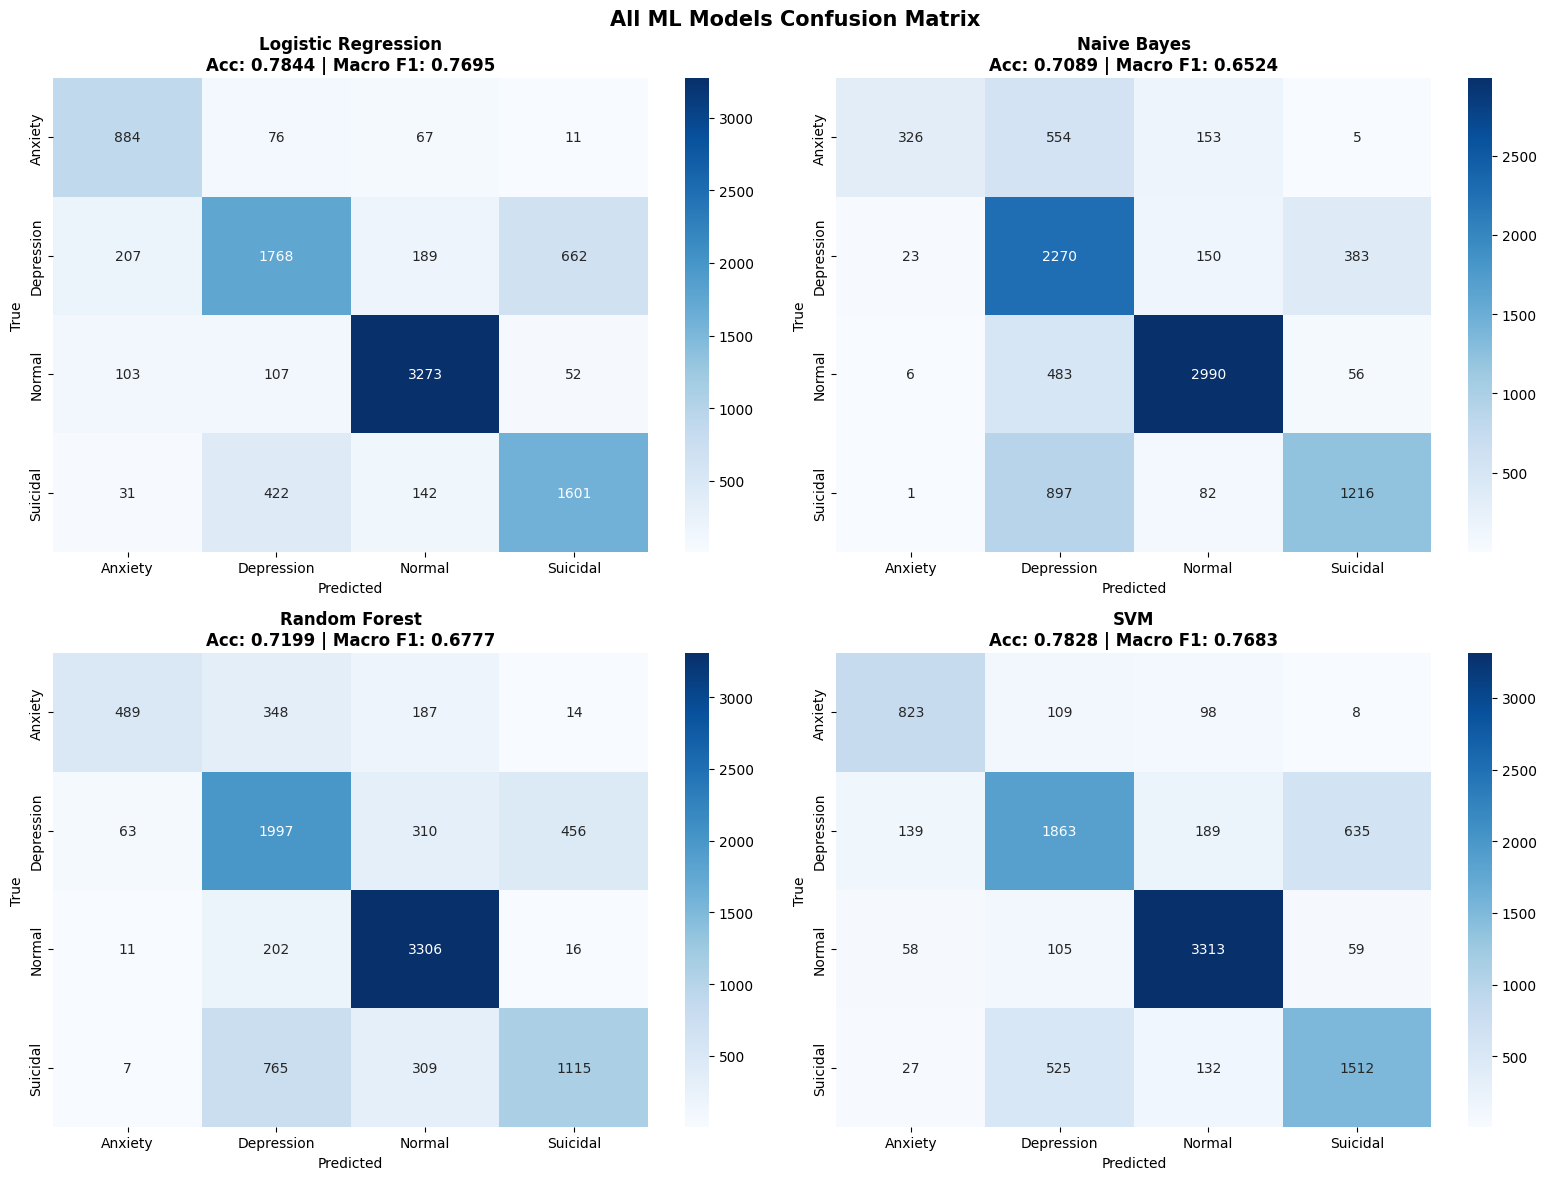

In [21]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

all_models = {
    'Logistic Regression': models['Logistic Regression'],
    'Naive Bayes': models['Naive Bayes'],
    'Random Forest': models['Random Forest'],
    'SVM': svm
}

for ax, (name, m) in zip(axes, all_models.items()):
    preds = m.predict(X_val)
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=ax
    )
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='macro')
    ax.set_title(f'{name}\nAcc: {acc:.4f} | Macro F1: {f1:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('All ML Models Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/ml_confusion_matrix.png', dpi=150)
plt.show()

### Step 9.4: Per Class F1 Comparison

Per Class F1 Scores:
            Logistic Regression  Naive Bayes  Random Forest     SVM
Anxiety                  0.7813       0.4677         0.6082  0.7894
Depression               0.6801       0.6458         0.6507  0.6864
Normal                   0.9084       0.8654         0.8647  0.9118
Suicidal                 0.7081       0.6307         0.5873  0.6857


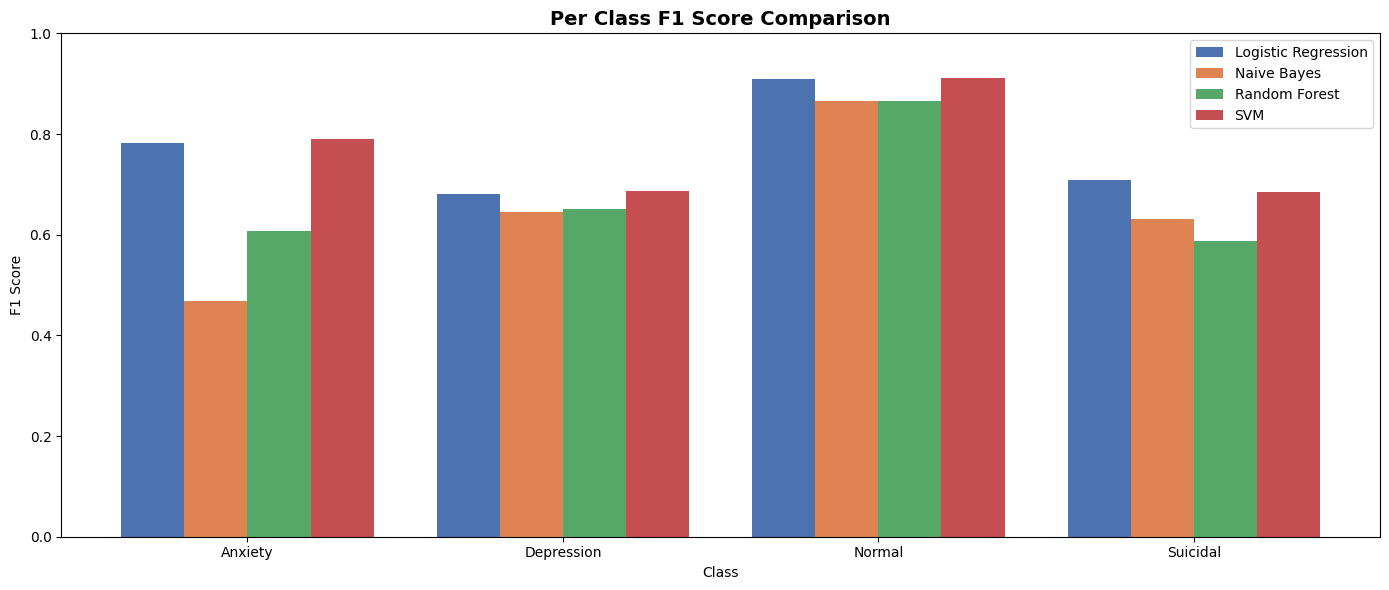

In [22]:
from sklearn.metrics import f1_score
import numpy as np

all_models = {
    'Logistic Regression': models['Logistic Regression'],
    'Naive Bayes': models['Naive Bayes'],
    'Random Forest': models['Random Forest'],
    'SVM': svm
}

class_f1_results = {}

for name, m in all_models.items():
    preds = m.predict(X_val)
    f1_per_class = f1_score(y_val, preds, average=None)
    class_f1_results[name] = f1_per_class

class_f1_df = pd.DataFrame(class_f1_results, index=label_encoder.classes_)
print("Per Class F1 Scores:")
print(class_f1_df.round(4))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_encoder.classes_))
width = 0.2
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for i, (name, color) in enumerate(zip(all_models.keys(), colors)):
    ax.bar(x + i * width, class_f1_df[name], width, label=name, color=color)

ax.set_title('Per Class F1 Score Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(label_encoder.classes_)
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('../outputs/per_class_f1_comparison.png', dpi=150)
plt.show()

### Step 9.5: Custom Text Testing on Best ML Model

In [24]:
test_texts = [
    "I feel great today, had a wonderful time with my friends",
    "I can't stop crying, everything feels hopeless and dark",
    "I don't want to live anymore, I think about ending it all",
    "My heart is racing, I can't breathe, I'm so scared and anxious",
    "I hate myself and I feel like a burden to everyone around me",
    "I have been having panic attacks every day, I can't function",
    "I want to kill myself, there is no point in going on anymore",
    "you've made it through another week, things are gonna be alright",
    "I don't feel depressed, I feel completely normal and happy",
    "I feel like dying but I know I won't do anything about it"
]

expected = [
    'Normal', 'Depression', 'Suicidal', 'Anxiety',
    'Depression', 'Anxiety', 'Suicidal', 'Normal',
    'Normal', 'Suicidal'
]

print(f"{'Text':<55} {'Expected':<12} {'LR Pred':<12} {'SVM Pred':<12} {'Match'}")
print("-" * 100)

for text, exp in zip(test_texts, expected):
    clean = preprocess_text(text)
    vec = tfidf.transform([clean])
    lr_pred = label_encoder.inverse_transform(models['Logistic Regression'].predict(vec))[0]
    svm_pred = label_encoder.inverse_transform(svm.predict(vec))[0]
    match = "✅" if lr_pred == exp else "❌"
    print(f"{text[:53]:<55} {exp:<12} {lr_pred:<12} {svm_pred:<12} {match}")

Text                                                    Expected     LR Pred      SVM Pred     Match
----------------------------------------------------------------------------------------------------
I feel great today, had a wonderful time with my frie   Normal       Normal       Normal       ✅
I can't stop crying, everything feels hopeless and da   Depression   Depression   Suicidal     ✅
I don't want to live anymore, I think about ending it   Suicidal     Suicidal     Suicidal     ✅
My heart is racing, I can't breathe, I'm so scared an   Anxiety      Anxiety      Anxiety      ✅
I hate myself and I feel like a burden to everyone ar   Depression   Depression   Depression   ✅
I have been having panic attacks every day, I can't f   Anxiety      Anxiety      Anxiety      ✅
I want to kill myself, there is no point in going on    Suicidal     Suicidal     Suicidal     ✅
you've made it through another week, things are gonna   Normal       Normal       Normal       ✅
I don't feel depressed